In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd

In [3]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [4]:
SST = loadmat("../../NHCS/Processed/SST_SSH.mat")
print(SST.keys())

dict_keys(['__header__', '__version__', '__globals__', 'SSH', 'SST'])


In [5]:
print(ds.mask_rho.shape)
mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))

(542, 602)


In [6]:
time = pd.date_range(start="1980-01",end="2016-01",freq='M')

ds_temp = xr.Dataset(
    data_vars={
        'SST':(("time", "lat","lon"), SST['SST'].transpose(2, 1, 0)*expanded_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)
ds_temp

/tmp/ipykernel_619200/1721827683.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    SST      (time, lat, lon) float64 1GB 20.19 20.18 20.24 ... nan nan nan

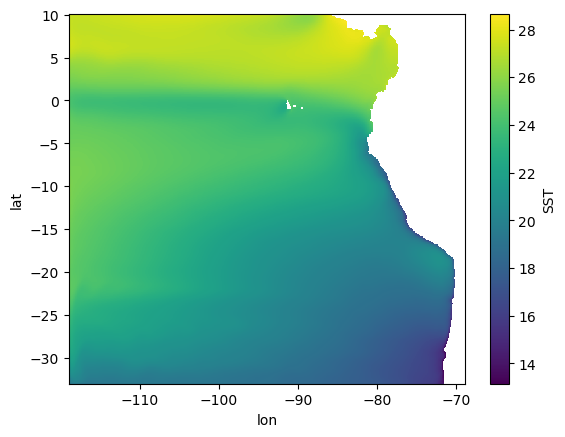

In [7]:
ds_temp.SST.mean(dim='time').plot()

## CUI

In [8]:
## kml to struct
import re
from xml.etree import ElementTree as ET
import numpy as np

def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [9]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

In [10]:
from matplotlib.path import Path
LON, LAT = np.meshgrid(ds_temp.lon,ds_temp.lat)
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

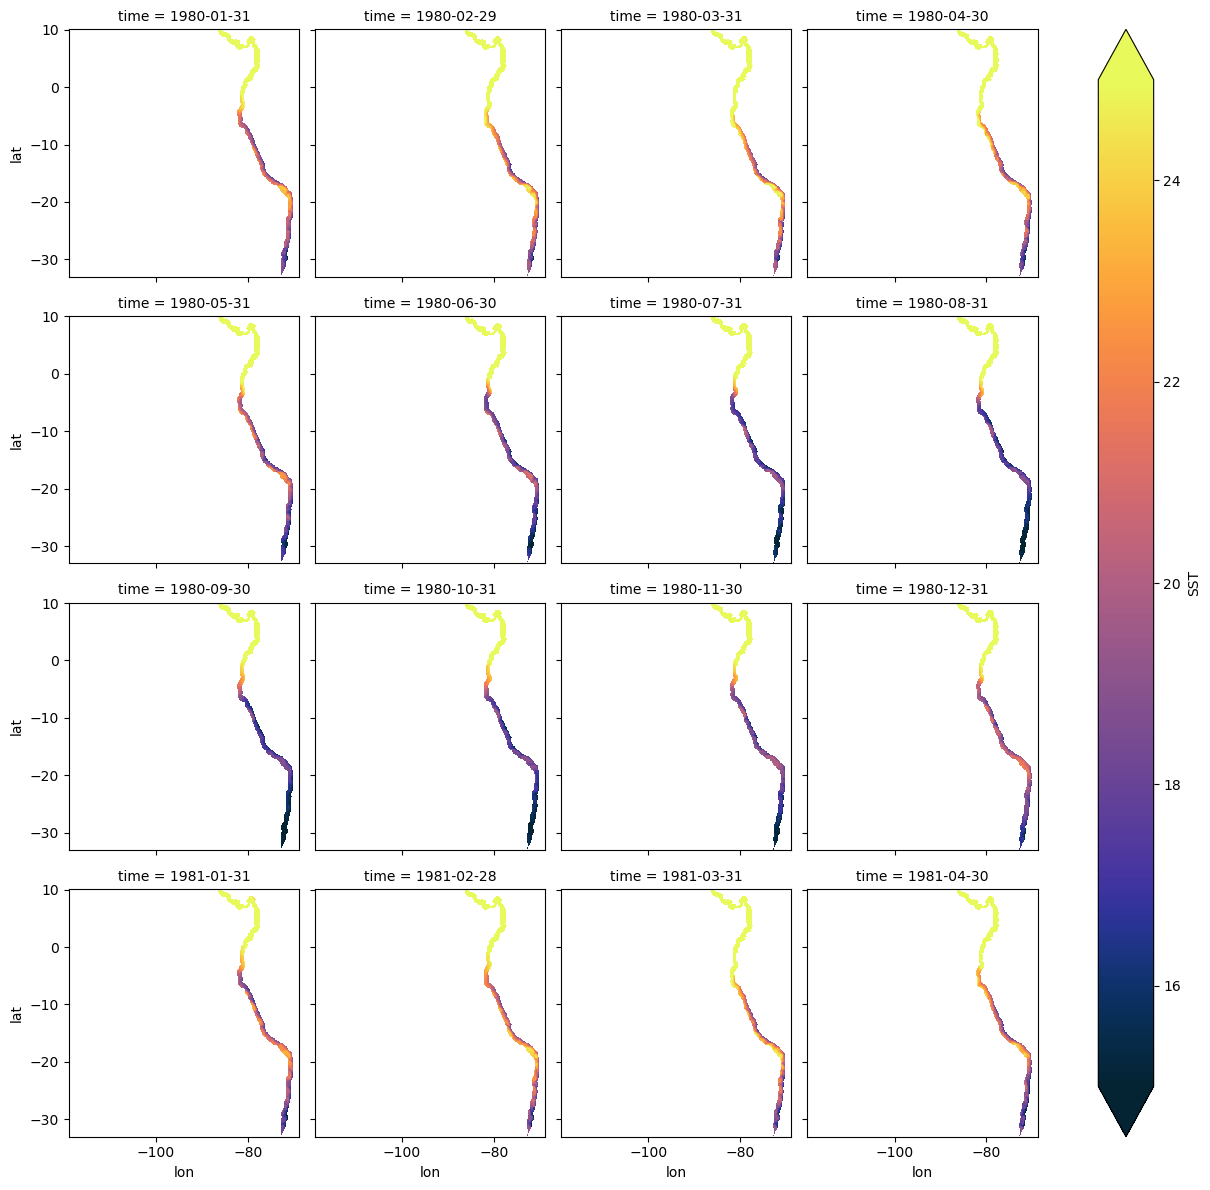

In [11]:
SST_inshore = ds_temp['SST'] * inshore_mask
SST_inshore.isel(time=slice(None,16)).plot(x="lon", y="lat", cmap=cm.thermal,
                                              col = 'time', col_wrap=4,
                                         vmin=15, vmax=25)

In [12]:
## Offshore 500km 
r5 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK500km.kml"
r6 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK600km.kml"

R5 = kml2struct(r5)
R6 = kml2struct(r6)

# Extract Lon and Lat from the first polygon
lonb5 = R5[0]["Lon"]
latb5 = R5[0]["Lat"]
lonb6 = R6[0]["Lon"]
latb6 = R6[0]["Lat"]

### cutting the 500km
polygon5 = Path(np.column_stack((lonb5, latb5)))
polygon6 = Path(np.column_stack((lonb6, latb6)))

# Check which points are inside the polygon
mask5 = polygon5.contains_points(lonlat_points).reshape(LON.shape)
mask6 = polygon6.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
offshore_mask5 = np.where(mask5, 1, np.nan)
offshore_mask6 = np.where(mask6, 1, np.nan)

/tmp/ipykernel_619200/4048778958.py:6: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label="Space Between Masks")


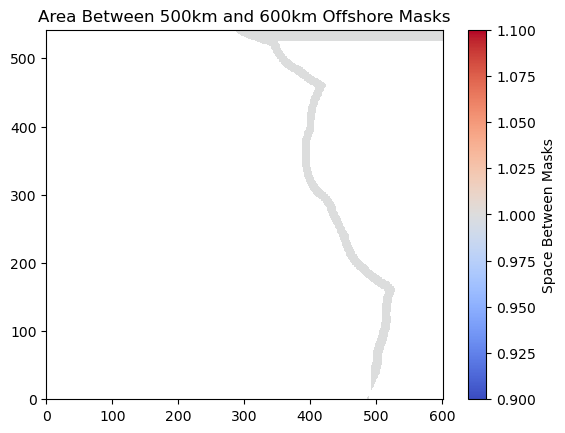

In [13]:
# Calculate the space between the two masks
space_between_masks = np.where((offshore_mask6 == 1) & (offshore_mask5 != 1), 1, np.nan)

# Plot the result
plt.pcolor(space_between_masks, cmap="coolwarm")
plt.colorbar(label="Space Between Masks")
plt.title("Area Between 500km and 600km Offshore Masks")
plt.show()

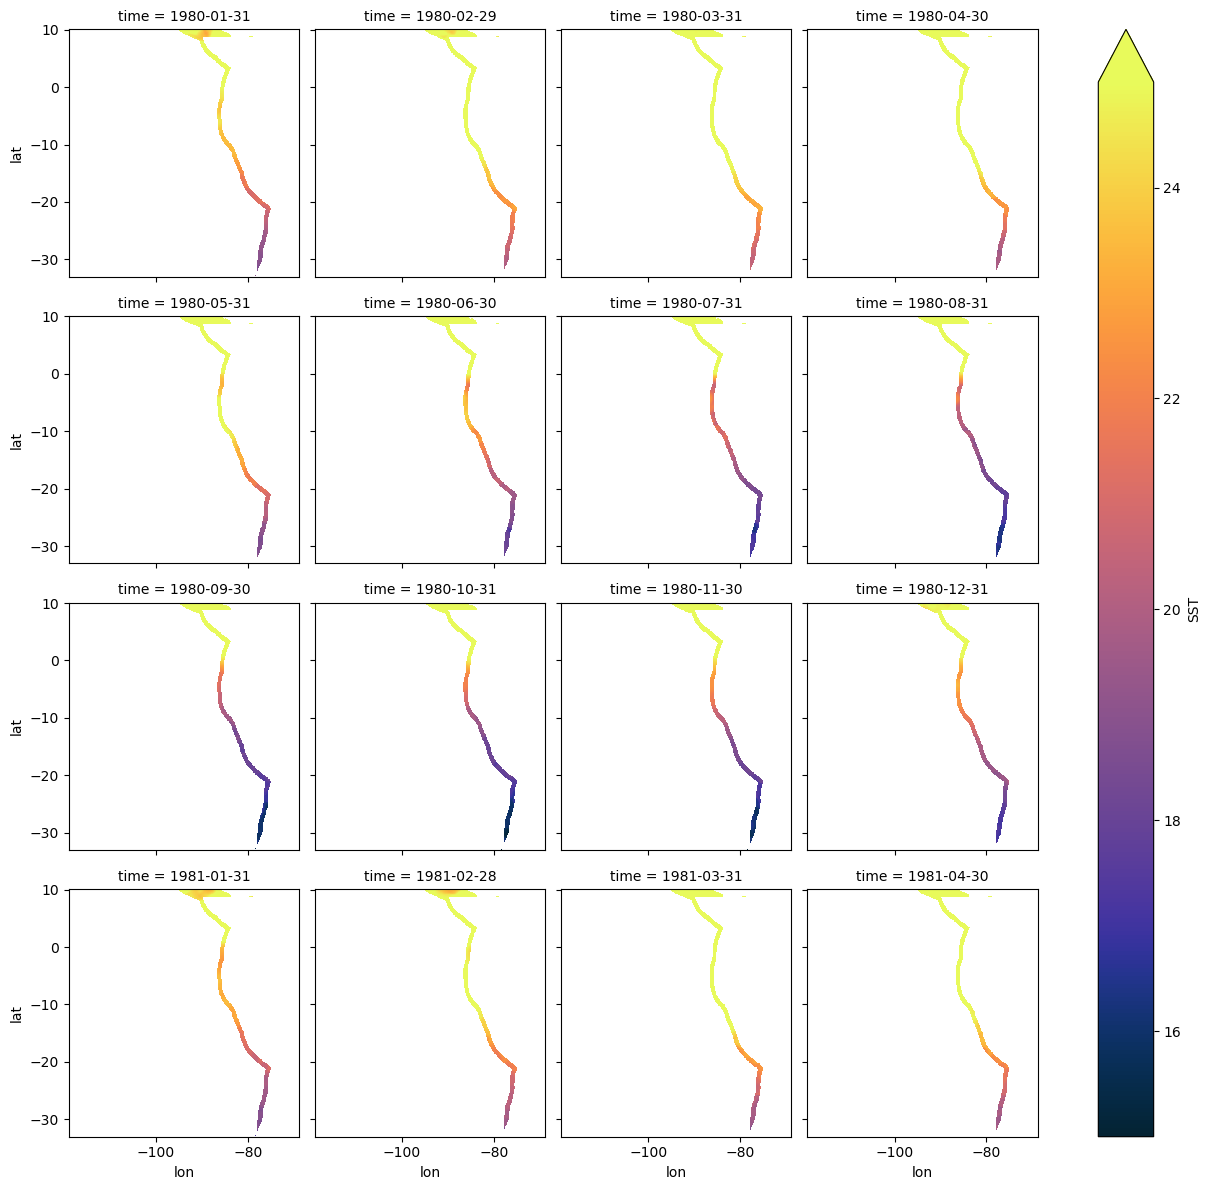

In [14]:
SST_offshore = ds_temp['SST'] * space_between_masks
# SST_offshore = SST['SST'] * offshore_mask5
SST_offshore.isel(time=slice(None,16)).plot(x="lon", y="lat", cmap=cm.thermal,
                                              col = 'time', col_wrap=4,
                                         vmin=15, vmax=25)

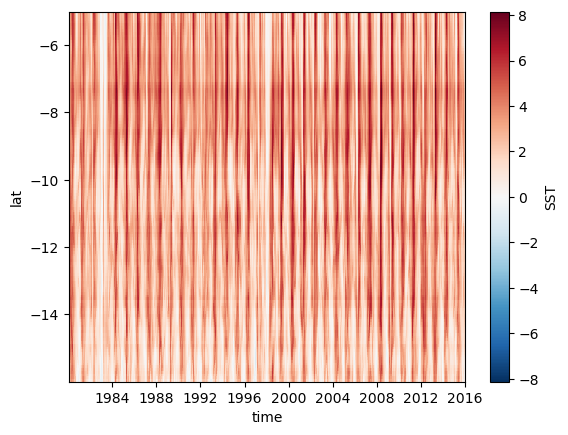

In [15]:
CUI_old = SST_offshore.mean(dim='lon') - SST_inshore.mean(dim='lon')
CUI_old.sel(lat=slice(-16,-5)).plot(x='time',y='lat')

In [16]:
def seasonality(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

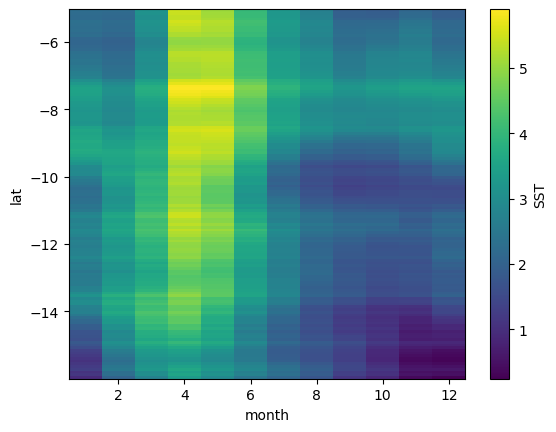

In [17]:
CUI_season = seasonality(CUI_old)
CUI_season.sel(lat=slice(-16,-5)).plot(x='month',y='lat')

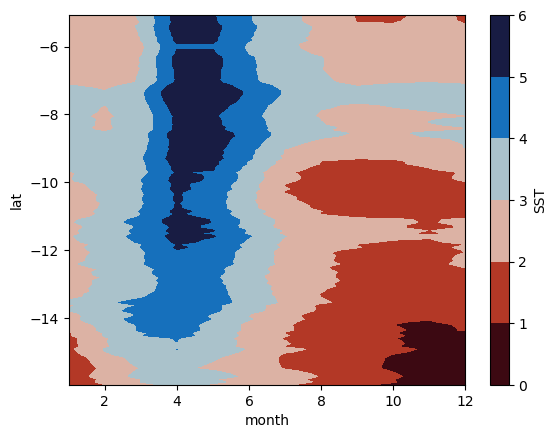

In [18]:
CUI_season.sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat',cmap=cm.balance_r)

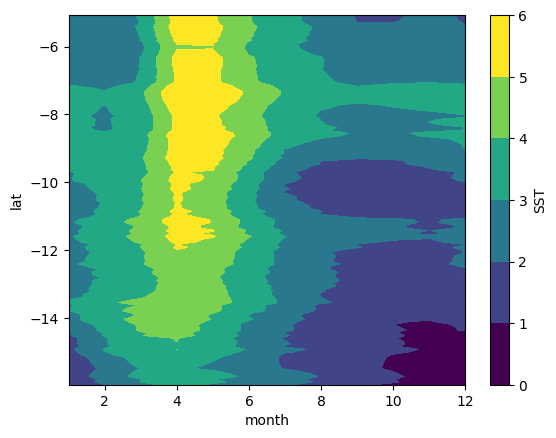

In [19]:
CUI_abs = abs(SST_offshore.mean(dim='lon') - SST_inshore.mean(dim='lon'))
CUI_abs_season = seasonality(CUI_abs)
CUI_abs_season.sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat')

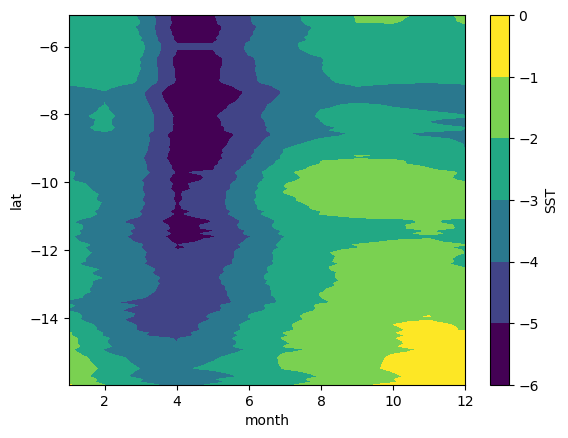

In [20]:
CUI_in = SST_inshore.mean(dim='lon') - SST_offshore.mean(dim='lon')
CUI_in_season = seasonality(CUI_in)
CUI_in_season.sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat')

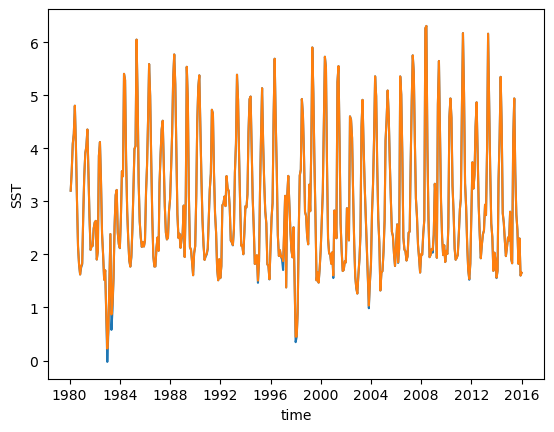

In [21]:
CUI_old.sel(lat=slice(-16,-5)).mean(dim='lat',skipna=True).plot()
CUI_abs.sel(lat=slice(-16,-5)).mean(dim='lat',skipna=True).plot()
# CUI_in.sel(lat=slice(-16,-5)).mean(dim='lat',skipna=True).plot()

## Salvatecci 2018

doi: 10.1111/gcb.13991Glob Change Biol. 2018;24:1055–1068. wileyonlinelibrary.com/journal/gcb © 2017 John Wiley & Sons Ltd | 1055

* Inshore: SST anomalies from the coastal area (12° to 17°S; 73° to 78°W). 
* Offshore: SST anomalies from theoffshore area (11 to 21°S; 80 to 90°W). 


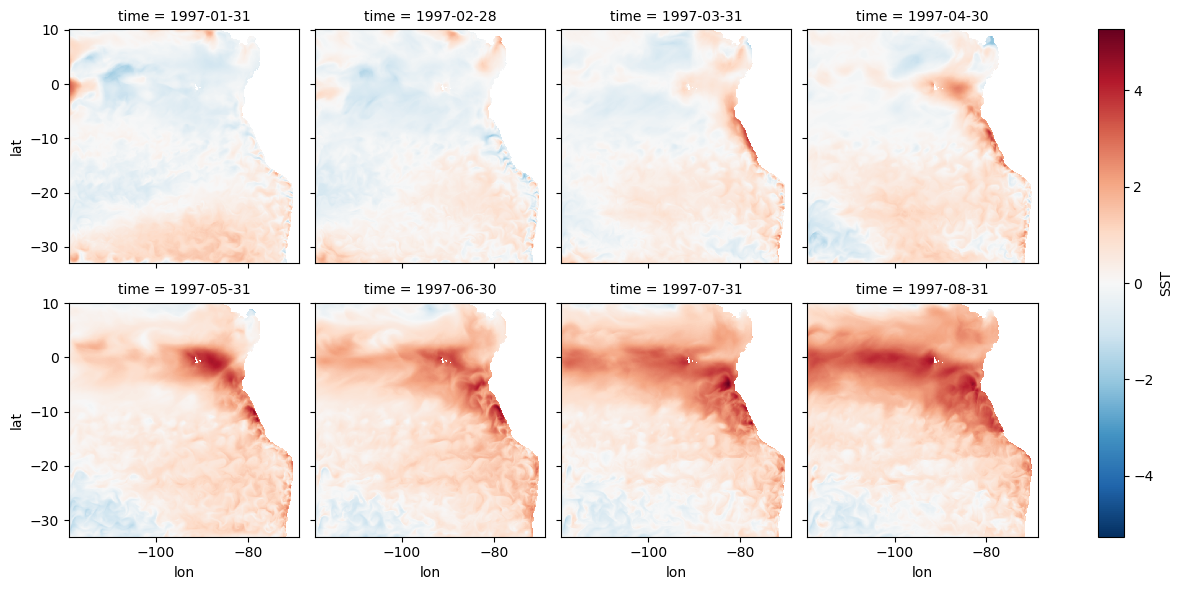

In [22]:
#Anomalies
SSTa = ds_temp.groupby("time.month") - seasonality(ds_temp)
SSTa.SST.sel(time=slice('1997-01','1997-08')).plot(col='time',col_wrap=4)

<xarray.Dataset> Size: 13MB
Dimensions:  (lon: 60, lat: 62, time: 432)
Coordinates:
  * lon      (lon) float64 480B -77.95 -77.87 -77.78 ... -73.2 -73.12 -73.03
  * lat      (lat) float64 496B -16.99 -16.91 -16.83 ... -12.24 -12.16 -12.07
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    SST      (time, lat, lon) float64 13MB 0.3873 0.4002 0.4226 ... nan nan nan

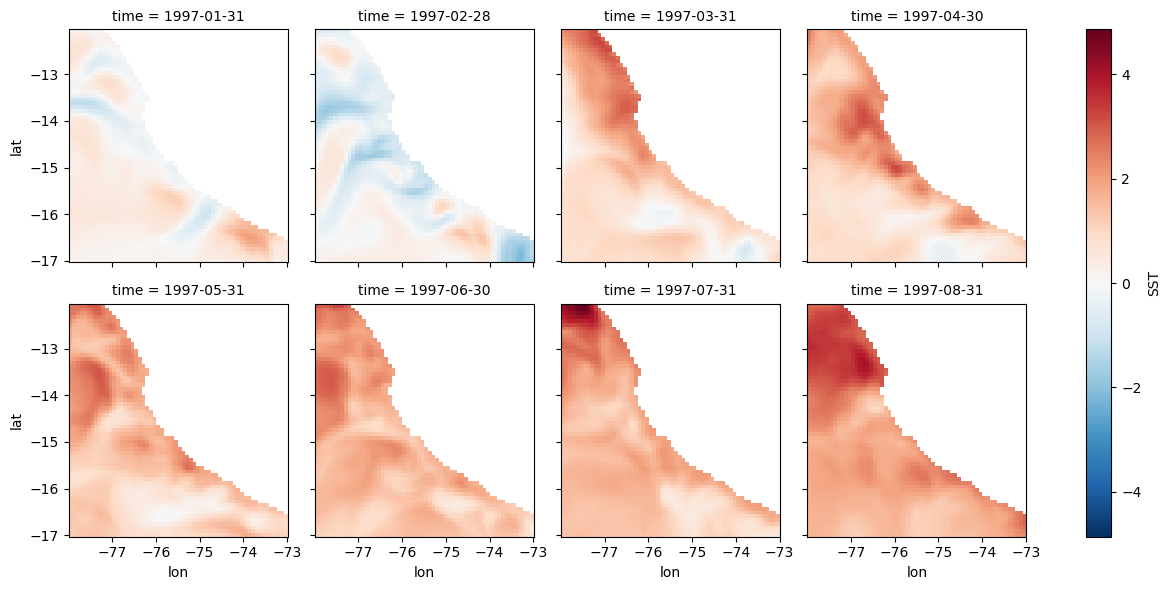

In [23]:
inshore = SSTa.sel(lat=slice(-17,-12),lon=slice(-78,-73))
inshore.sel(time=slice('1997-01','1997-08')).SST.plot(col='time',col_wrap=4)
inshore

<xarray.Dataset> Size: 52MB
Dimensions:  (lon: 120, lat: 125, time: 432)
Coordinates:
  * lon      (lon) float64 960B -89.95 -89.87 -89.78 ... -80.2 -80.12 -80.03
  * lat      (lat) float64 1kB -20.93 -20.85 -20.78 ... -11.18 -11.1 -11.01
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    SST      (time, lat, lon) float64 52MB 0.03757 0.04056 ... 0.7938 0.7928

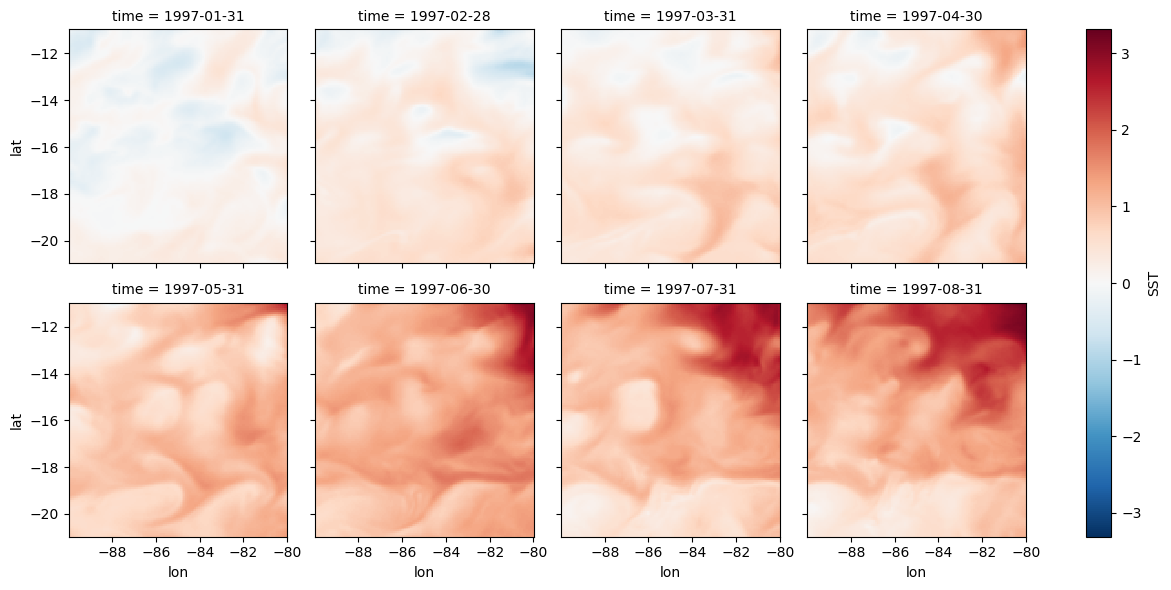

In [24]:
#Offshore: SST anomalies from theoffshore area (11 to 21°S; 80 to 90°W).
offshore= SSTa.sel(lat=slice(-21,-11),lon=slice(-90,-80))
offshore.SST.sel(time=slice('1997-01','1997-08')).plot(col='time',col_wrap=4)
offshore

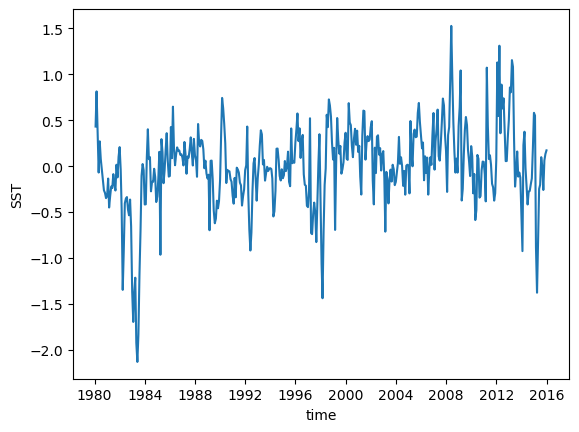

In [25]:
SST_ui = offshore.mean(dim={'lat','lon'},skipna=True) - inshore.mean(dim={'lat','lon'},skipna=True)
SST_ui.SST.plot()
# SST_ui.time=slice('1997-01','1997-08').SST.plot(col='time',col_wrap=4)
# offshore - inshore.time=slice('1997-01','1997-08').SST.plot(col='time',col_wrap=4)

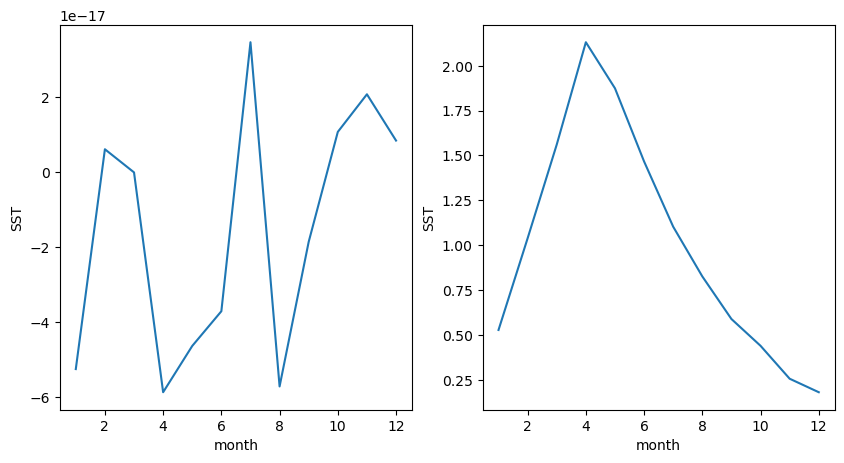

In [26]:
fig,ax= plt.subplots(1,2,figsize=(10,5))

seasonality(SST_ui).SST.plot(ax=ax[0])
CUI_season.mean(dim='lat').plot(ax=ax[1])


In [27]:
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

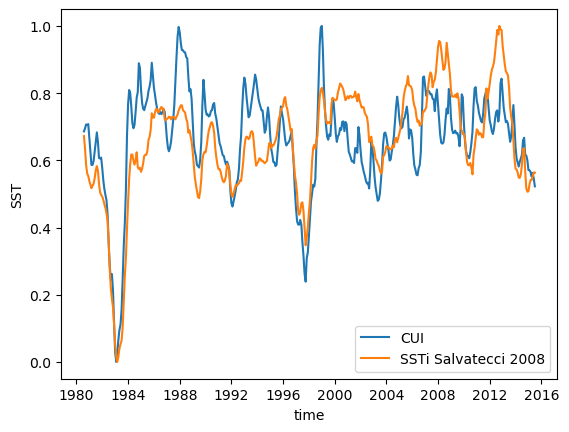

In [28]:
normalize(CUI_old.sel(lat=slice(-16,-5)).mean(dim='lat',skipna=True).rolling(time=13,center=True).mean()).plot(label='CUI')
normalize(SST_ui.SST.rolling(time=13,center=True).mean()).plot(label='SSTi Salvatecci 2008')
plt.legend()

## CHLOR

In [31]:
CHL = xr.open_dataset('../../NHCS/hincast_1980-2015/Chlorophyll.nc',
                            chunks = {'time':1})
# ds_chl = ds_chl.rename({'latitude':'lat','longitude':'lon'})
CHL

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
    s_rho    float64 8B ...
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
Data variables:
    chla     (time, lat, lon) float64 1GB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>

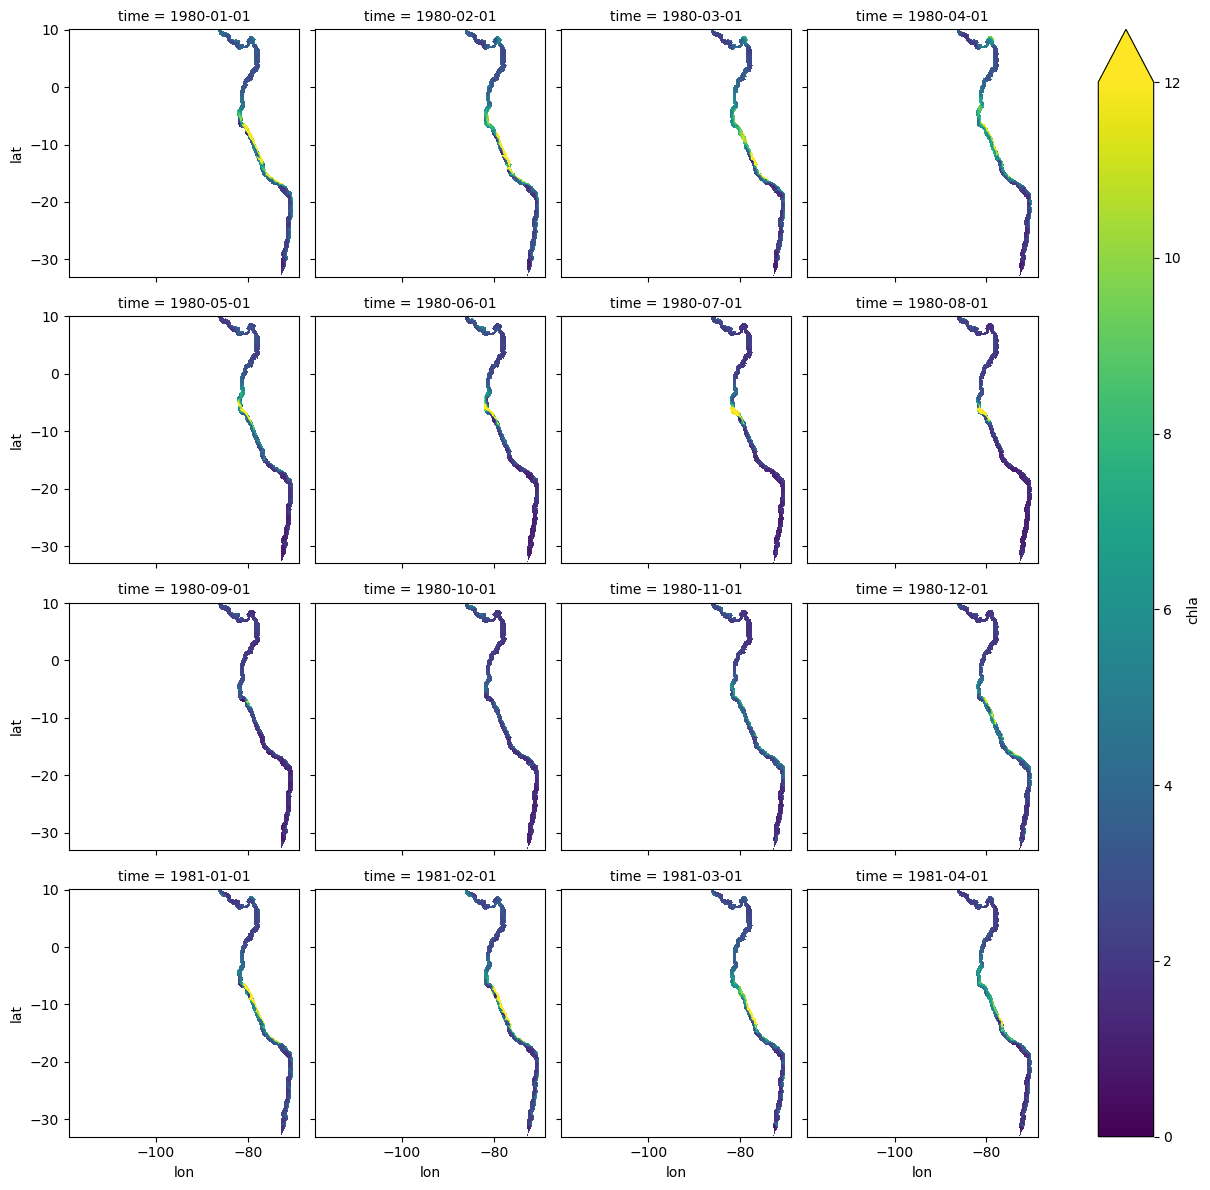

In [32]:
CHL.chla.isel(time=slice(None,16)).plot(x='lon',y='lat',
                                          col='time',col_wrap=4,vmin=0, vmax=12)


In [33]:
def seasonality(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

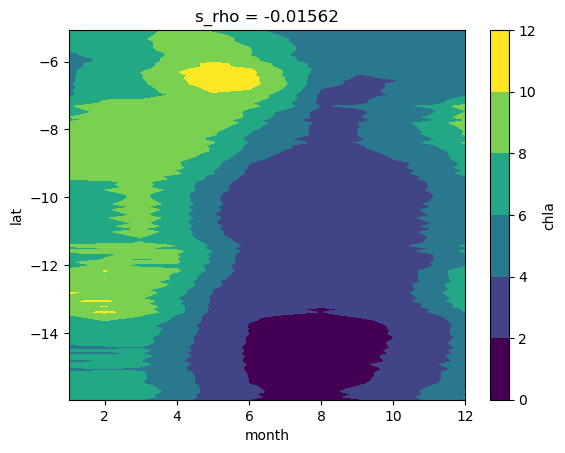

In [37]:
chl_season = seasonality(CHL)
chl_season.mean(dim='lon').chla.sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat')

## CROCO $W_{MLD}$ 

In [38]:
WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")
print(WMLD_data.keys())

WMLD_ds_ = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

WMLD_ds_

dict_keys(['__header__', '__version__', '__globals__', 'MLD', 'WMLD'])


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    WMLD     (time, lat, lon) float64 1GB 4.613e-08 4.613e-08 ... 0.0 0.0

In [39]:
mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)

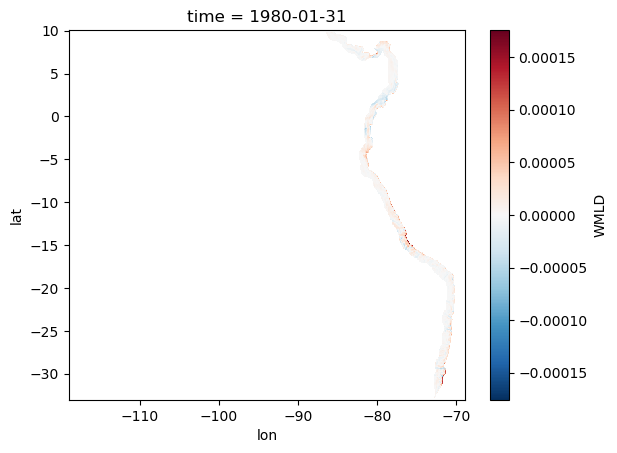

In [40]:
WMLD_ds_['WMLD'] = WMLD_ds_['WMLD'] * inshore_mask *mask_nan
WMLD_ds_.isel(time=0).WMLD.plot()

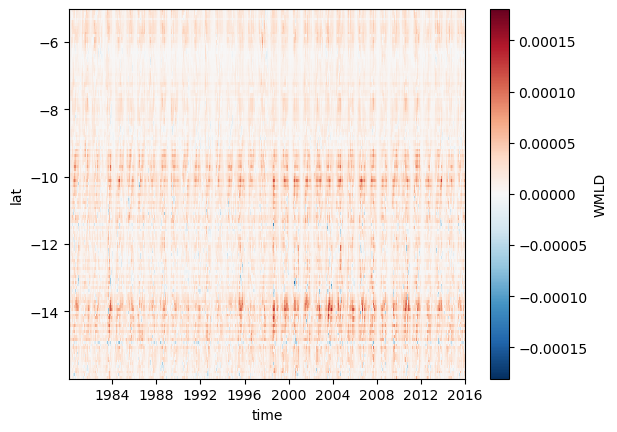

In [41]:
WMLD_ds_.WMLD.mean('lon').sel(lat=slice(-16,-5)).plot(x='time')

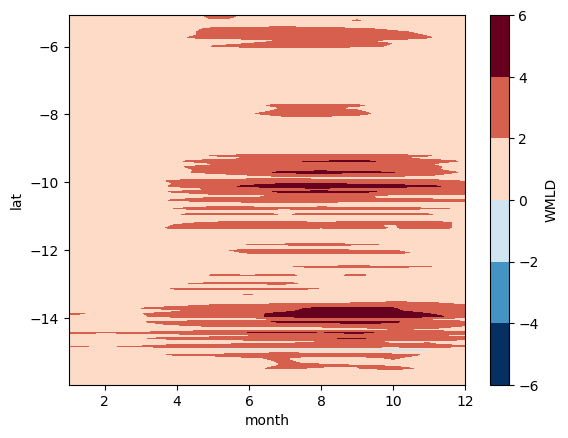

In [42]:
wmld_season = seasonality(WMLD_ds_*86400)
wmld_season.WMLD.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat')

In [43]:
wmld = wmld_season.WMLD.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5))
wmld

<xarray.DataArray 'WMLD' (month: 12, lat: 134)> Size: 13kB
array([[0.41779647, 0.45488965, 0.78612464, ..., 0.63653185, 0.59616999,
        0.57915203],
       [0.53104738, 0.44445168, 0.75152794, ..., 0.3508197 , 0.26349673,
        0.26922087],
       [0.74419704, 0.60776008, 0.94439907, ..., 0.5392326 , 0.45212999,
        0.47102938],
       ...,
       [1.14580257, 0.43195601, 1.48199048, ..., 1.51877152, 1.43373816,
        1.40450232],
       [0.64693865, 0.76825107, 1.53288881, ..., 1.39016408, 1.34878439,
        1.38468425],
       [0.56919236, 0.49237908, 0.91831397, ..., 1.12863251, 1.00063096,
        0.92242787]])
Coordinates:
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

/tmp/ipykernel_619200/3072581113.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels,fontsize=16)


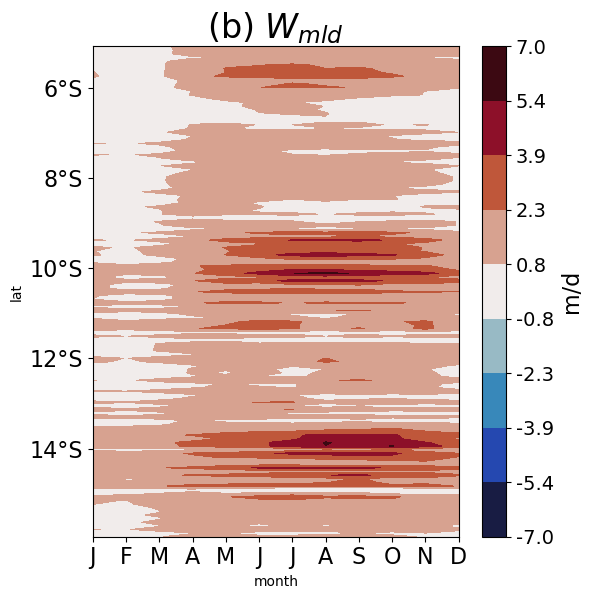

In [44]:
from matplotlib.colors import TwoSlopeNorm 
fig, ax = plt.subplots(figsize=(6,6))

# np.linspace(-5, 5, 10) 
vmin=-7; vmax=7
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

levels=np.linspace(vmin,vmax,10)

cf=wmld.plot.contourf(x='month',vmin=vmin, vmax=vmax,cmap = cm.balance,
                                                                 norm=norm,levels=levels,add_colorbar=False)
ax = plt.gca()
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('m/d',fontsize=16)
cbar.ax.set_yticklabels([f"{tick:.1f}" for tick in levels], fontsize=14)  # 1 decimal formatting

yticks = ax.get_yticks()  # Get current y-tick positions

# Format labels with °S for negative values (Southern Hemisphere)
new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
ax.set_yticklabels(new_labels,fontsize=16)

plt.title('(b) $W_{mld}$',fontsize=24)
plt.tight_layout()

months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
plt.xticks(range(1, 13), months,fontsize=16)  # Assuming your data has 12 points (one per month)

# plt.savefig('Figures/wmld_season_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

In [45]:
Puertos = {
       "Pisco":  [-13.69388889,  -76.22416667],
    "Callao":   [-12.0575,  -77.15305556],
    "Chimbote": [-9.076666667,  -78.61472222],
    "Paita":    [-5.078055556,  -81.10638889],
    }

In [47]:
mean_WMLD = WMLD_ds_.WMLD.sel(lat=slice(-16, -5), lon=slice(-84, -73.5)).mean(dim='time',skipna=True)
mean_WMLD = xr.where(mean_WMLD == 0, np.nan, mean_WMLD)

lat = mean_WMLD.lat.values
lon = mean_WMLD.lon.values
loni, lati = np.meshgrid(lon, lat)

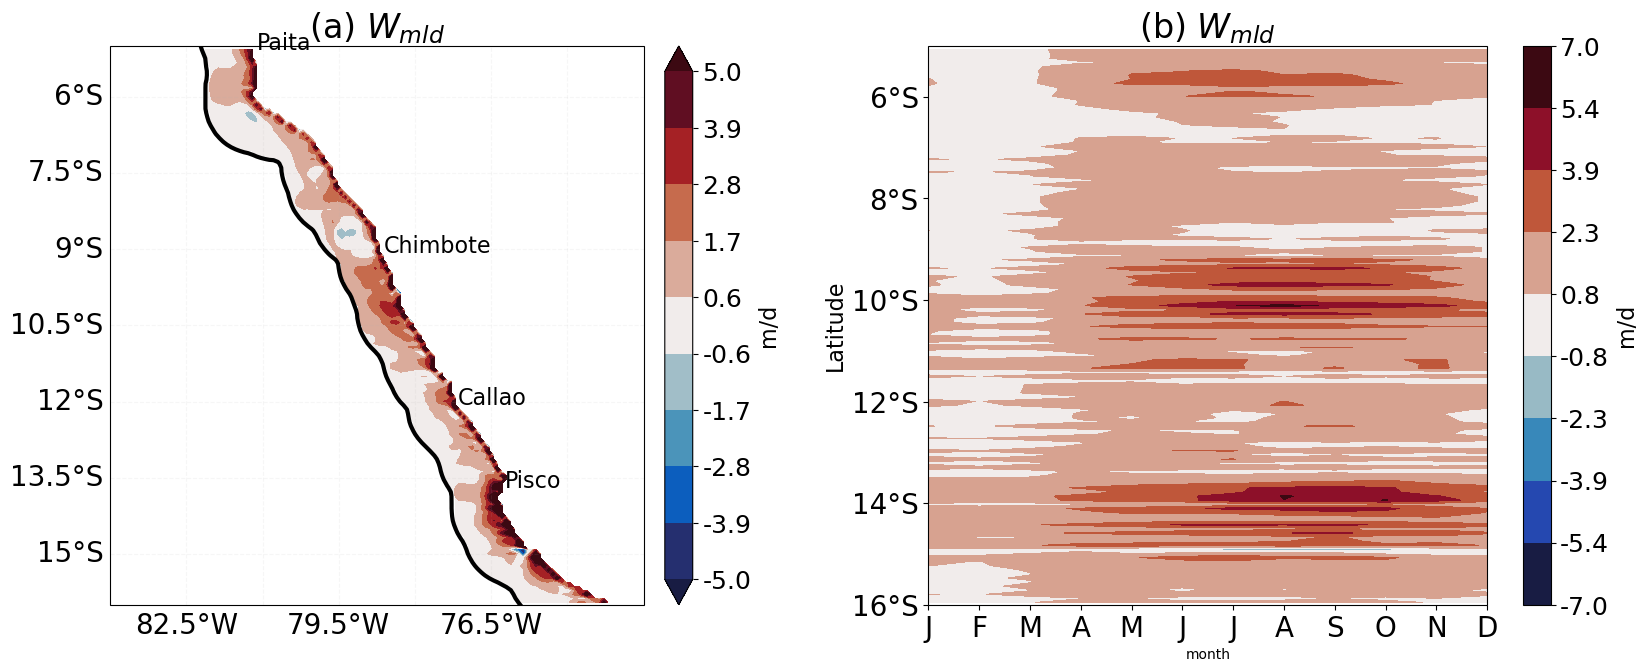

In [48]:
import cartopy.crs as ccrs

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18*1.1, 6*1.1), 
                              gridspec_kw={'width_ratios': [1.5, 1]},
                              subplot_kw={'projection': ccrs.PlateCarree()})

# First subplot (map)
# --------------------------------------------------------------------------
# Set up levels and normalization
levels = np.linspace(-5, 5, 10)
vmin, vmax = levels.min(), levels.max()
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Plot the data using contourf
cs = ax1.contourf(loni, lati, mean_WMLD*86400, cmap=cm.balance, norm=norm, 
                 extend='both', levels=levels)

# Add port labels
for key in Puertos:
    x, y = Puertos[key][1], Puertos[key][0]
    ax1.text(x, y, key, fontsize=16)

# Add colorbar
cbar1 = plt.colorbar(cs, ax=ax1, orientation='vertical', pad=0.02, fraction=0.1)
cbar1.set_label('m/d', fontsize=16)
cbar1.set_ticklabels([f"{tick:.1f}" for tick in levels], fontsize=18)

# # Add map features
# land = cfeature.NaturalEarthFeature(
#     category='physical',
#     name='land',
#     scale='10m',
#     facecolor='lightgray',
#     edgecolor=None
# )
# ax1.add_feature(land, alpha=1)
# ax1.add_feature(cfeature.LAND, edgecolor='grey')
ax1.set_title('(a) $W_{mld}$', fontsize=24)

# Configure gridlines
gl = ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.1)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 20}
gl.ylabel_style = {'size': 20}

# Set map extent
ax1.set_extent([-84, -73.5, -16, -5])
ax1.plot(lonb1, latb1, color='black', linewidth=3)

# Second subplot (seasonal cycle)
# --------------------------------------------------------------------------
# Set up levels and normalization
vmin, vmax = -7, 7
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
levels = np.linspace(vmin, vmax, 10)

# Plot the seasonal cycle
cf = wmld.plot.contourf(ax=ax2, x='month', vmin=vmin, vmax=vmax, 
                          cmap=cm.balance, norm=norm, levels=levels, 
                          add_colorbar=False)

# Add colorbar
cbar2 = plt.colorbar(cf, ax=ax2)
cbar2.set_label('m/d', fontsize=16)
cbar2.ax.set_yticklabels([f"{tick:.1f}" for tick in levels], fontsize=18)

# Format y-axis labels
yticks = ax2.get_yticks()
new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
ax2.set_yticks(yticks)
ax2.set_yticklabels(new_labels, fontsize=20)
ax2.set_ylabel('Latitude',fontsize=16)
ax2.set_ylim(-16,-5)

# Configure x-axis
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(months, fontsize=20)
ax2.set_title('(b) $W_{mld}$', fontsize=24)

# Adjust layout
plt.tight_layout()

# Save or show
# plt.savefig('Figures/paper/combined_WMLD_plots_GOOD.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

## Nitrogen

In [49]:
nitro = loadmat("../../NHCS/Processed/Nitrogen.mat")
print(nitro.keys())

dict_keys(['__header__', '__version__', '__globals__', 'TN_MLD', 'TN_Surf'])


In [50]:
ds_nitro = xr.Dataset(
    data_vars={
        'Nitro_mld':(("time", "lat","lon"), nitro['TN_MLD'].transpose(2, 1, 0)*expanded_mask),
        'Nitro_surf':(("time", "lat","lon"), nitro['TN_Surf'].transpose(2, 1, 0)*expanded_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)
ds_nitro

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon         (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat         (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.869 9.951 10.03
  * time        (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    Nitro_mld   (time, lat, lon) float64 1GB 0.1585 0.1588 0.1642 ... nan nan
    Nitro_surf  (time, lat, lon) float64 1GB 0.1585 0.1588 0.1642 ... nan nan

In [51]:
ds_nitro = ds_nitro * inshore_mask

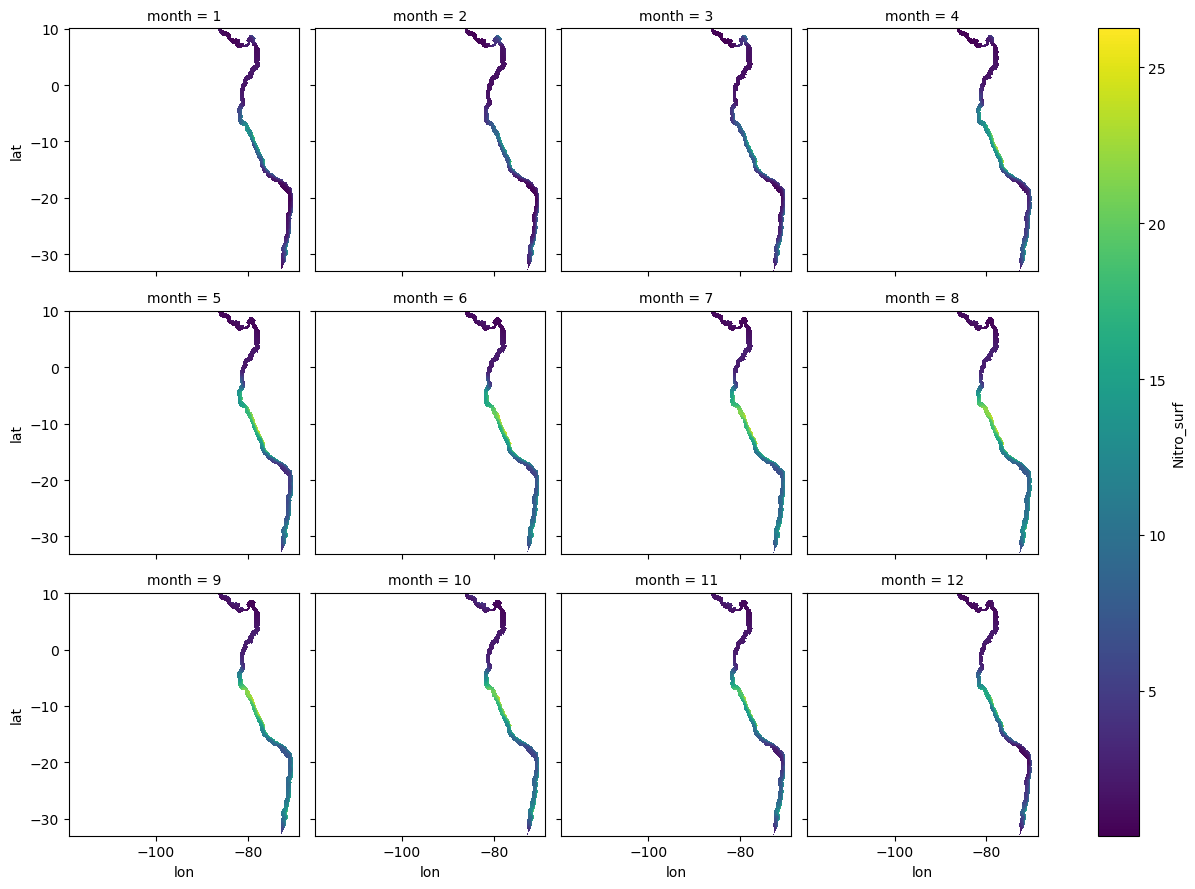

In [52]:
N_season = seasonality(ds_nitro)
N_season.Nitro_surf.plot(col='month',col_wrap=4)

Text(0.5, 1.0, '$N_{Surf - mld}$')

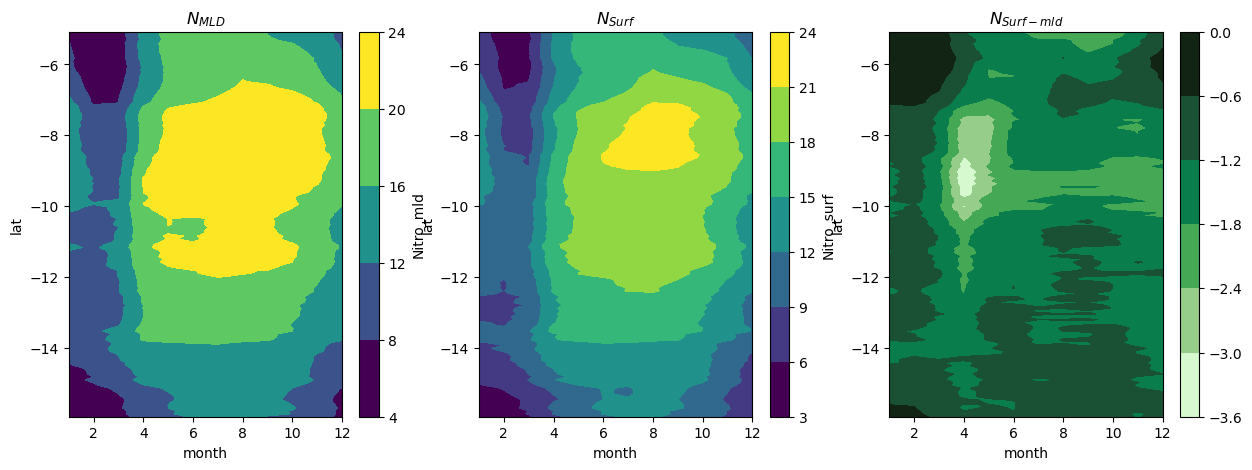

In [53]:
Ndiff_season = N_season.Nitro_surf - N_season.Nitro_mld
fig,ax =  plt.subplots(1, 3, figsize=(15, 5), sharex=True)
N_season.Nitro_mld.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat',ax=ax[0])
ax[0].set_title('$N_{MLD}$')
N_season.Nitro_surf.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat',ax=ax[1])
ax[1].set_title('$N_{Surf}$')
Ndiff_season.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat',cmap=cm.algae,ax=ax[2])
ax[2].set_title('$N_{Surf - mld}$')

In [54]:
N_ts = ds_nitro.groupby('time.month') - N_season
N_ts['Ndiff'] = N_ts.Nitro_surf - N_ts.Nitro_mld

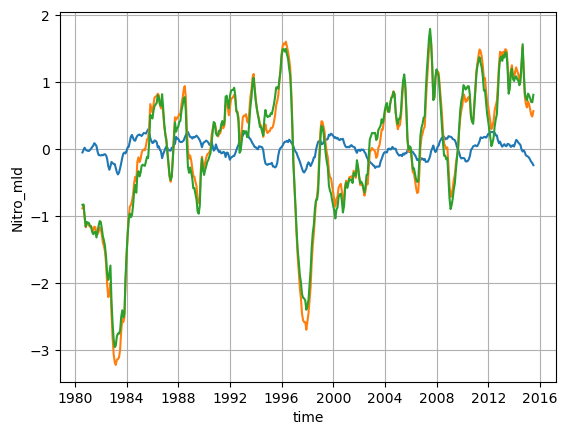

In [55]:
N_ts.Ndiff.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'),skipna=True).rolling(time=13,center=True).mean().plot()
N_ts.Nitro_surf.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'),skipna=True).rolling(time=13,center=True).mean().plot()
N_ts.Nitro_mld.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'),skipna=True).rolling(time=13,center=True).mean().plot()
plt.grid()

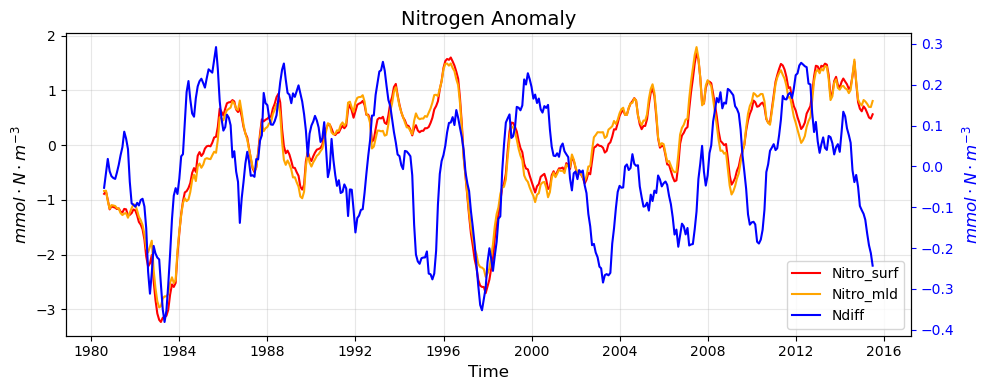

In [56]:
# import matplotlib.pyplot as plt

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot Nitro_surf and Nitro_mld on primary axis (left)
N_ts.Nitro_surf.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'), skipna=True)\
    .rolling(time=13, center=True).mean().plot(ax=ax1, color='red', label='Nitro_surf')
N_ts.Nitro_mld.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'), skipna=True)\
    .rolling(time=13, center=True).mean().plot(ax=ax1, color='orange', label='Nitro_mld')

# Create secondary axis (right)
ax2 = ax1.twinx()

# Plot Ndiff on secondary axis (right)
N_ts.Ndiff.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'), skipna=True)\
    .rolling(time=13, center=True).mean().plot(ax=ax2, color='blue', label='Ndiff')

# Customize the plot
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('$mmol \cdot N \cdot m^{-3}$', fontsize=12, color='black')
ax2.set_ylabel('$mmol \cdot N \cdot m^{-3}$', fontsize=12, color='blue')

# Set colors for y-axis labels to match line colors
# ax1.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='y', colors='blue')

# Add legend - combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

# Add grid
ax1.grid(True, alpha=0.3)

plt.title('Nitrogen Anomaly', fontsize=14)
plt.tight_layout()
plt.show()

## Seasonality structure

/tmp/ipykernel_619200/3249054082.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_yticklabels(new_labels, fontsize=12)
/tmp/ipykernel_619200/3249054082.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_yticklabels(new_labels, fontsize=12)
/tmp/ipykernel_619200/3249054082.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_yticklabels(new_labels, fontsize=12)


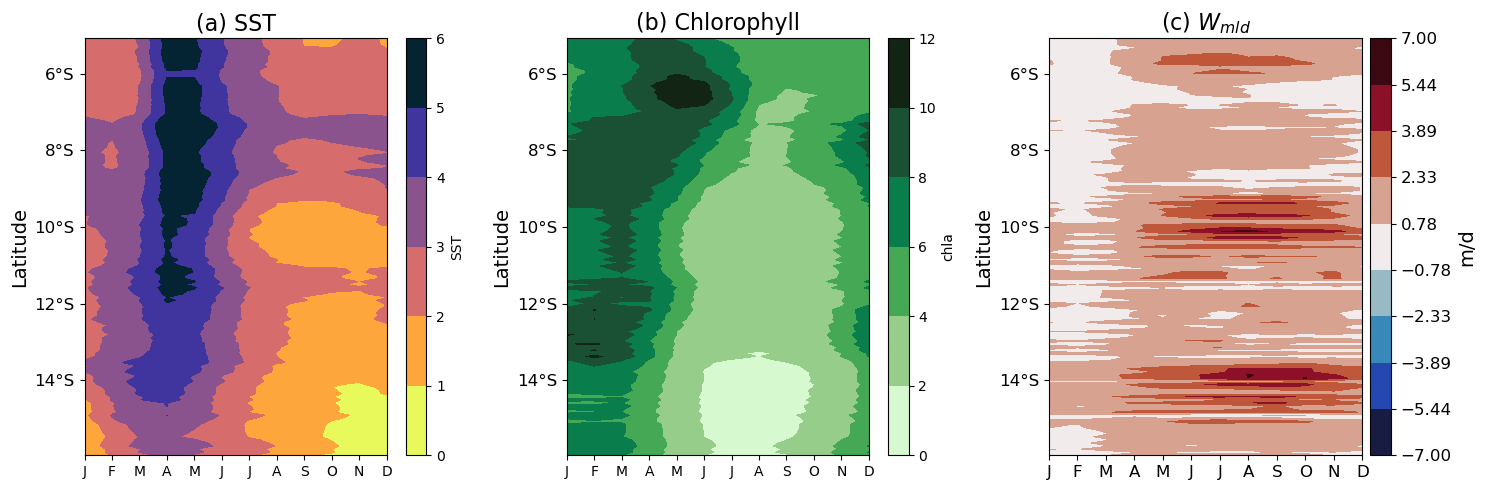

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from cmocean import cm # Make sure you have cmocean installed

# Create figure with 3 subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
plt.subplots_adjust(hspace=0.3)  # Adjust vertical spacing

# --- Plot 1: SST ---
CUI_season.sel(lat=slice(-16, -5)).plot.contourf(
    x='month', y='lat', cmap=cm.thermal_r, ax=ax[0], add_colorbar=True)
ax[0].set_title('(a) SST', fontsize=16)
ax[0].set_ylabel('Latitude', fontsize=14)

# --- Plot 2: Chlorophyll ---
chl_season.chla.sel(lat=slice(-16,-5)).mean(dim='lon',skipna=True).plot.contourf(
    x='month', y='lat', cmap=cm.algae, ax=ax[1], add_colorbar=True)
ax[1].set_title('(b) Chlorophyll', fontsize=16)
ax[1].set_ylabel('Latitude', fontsize=14)

# --- Plot 3: Wmld ---
vmin, vmax = -7, 7
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
levels = np.linspace(vmin, vmax, 10)

cf = wmld.plot.contourf(
    x='month', y='lat',
    cmap=cm.balance,
    norm=norm,
    levels=levels,
    add_colorbar=False,
    ax=ax[2]
)
ax[2].set_title('(c) $W_{mld}$', fontsize=16)
ax[2].set_ylabel('Latitude', fontsize=14)

# Add common colorbar for Wmld
cbar = fig.colorbar(cf, ax=ax[2], orientation='vertical', pad=0.02)
cbar.set_label('m/d', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Format y-axis labels for all subplots
for a in ax:
    yticks = a.get_yticks()
    new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
    a.set_yticklabels(new_labels, fontsize=12)
    a.set_xlabel('')  # Remove x-label from upper plots

# Set common x-axis properties
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
ax[2].set_xticks(range(1, 13))
ax[2].set_xticklabels(months, fontsize=12)
# ax[2].set_xlabel('Month', fontsize=14)

plt.tight_layout()
# plt.savefig('Figures/combined_plot.png', dpi=300, bbox_inches='tight')
plt.show()

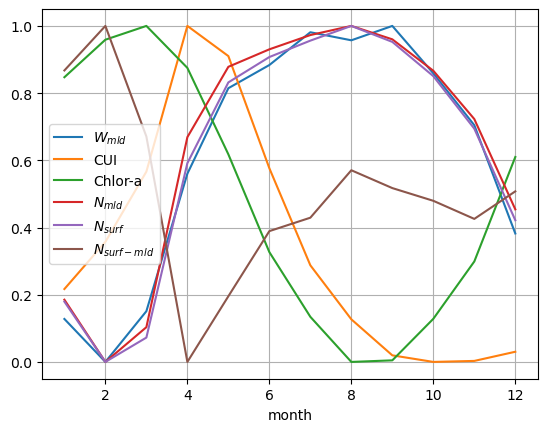

In [68]:

normalize(wmld.sel(lat=slice(-16, -5)).mean(dim='lat')).plot(label='$W_{mld}$')
normalize(CUI_season.sel(lat=slice(-16, -5)).mean(dim='lat')).plot(label='CUI')
normalize(chl_season.chla.sel(lat=slice(-16, -5)).mean(dim=('lat','lon'))).plot(label='Chlor-a')
normalize(N_season.Nitro_mld.sel(lat=slice(-16, -5)).mean(dim=('lat','lon'),skipna=True)).plot(label='$N_{mld}$')
normalize(N_season.Nitro_surf.sel(lat=slice(-16, -5)).mean(dim=('lat','lon'),skipna=True)).plot(label='$N_{surf}$')
normalize(Ndiff_season.sel(lat=slice(-16, -5)).mean(dim=('lat','lon'),skipna=True)).plot(label='$N_{surf-mld}$')
plt.grid()
plt.legend()

* include BEUTI vs Chlor

### Upwelling versus MLD

In [63]:
time = pd.date_range(start='1980-01', end='2016-01', freq='M')
MLD = loadmat("../../NHCS/Processed/WMLD_MLD.mat")

MLD_ds = xr.Dataset(
    data_vars={
        'MLD': (("time", "lat","lon"), MLD['MLD'].transpose(2, 1, 0)*expanded_mask* inshore_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

MLD_ds

/tmp/ipykernel_3867943/2136443538.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='1980-01', end='2016-01', freq='M')


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB nan nan nan nan ... nan nan nan nan

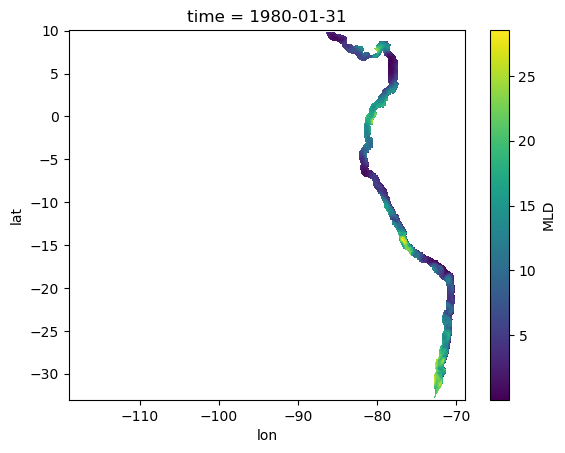

In [64]:
MLD_ds.MLD.isel(time=0).plot()

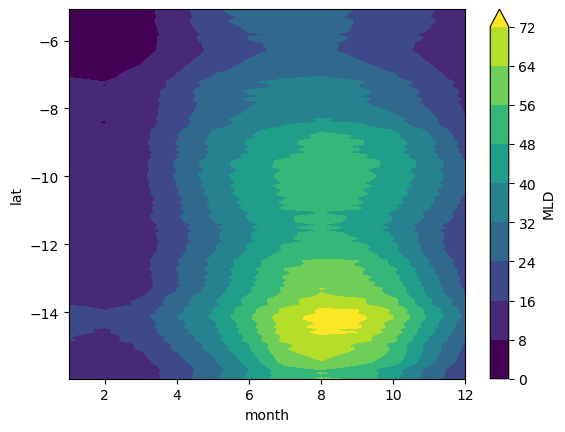

In [75]:
seasonality(MLD_ds).mean('lon').sel(lat=slice(-16,-5)).MLD.plot.contourf(x='month',levels=10,robust=True)

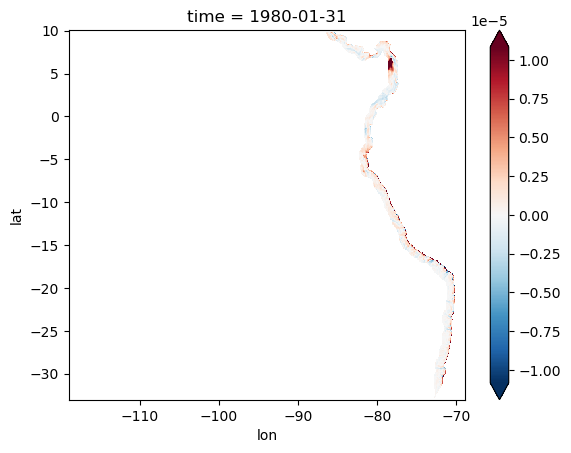

In [98]:
UP_MLD = WMLD_ds_.WMLD/MLD_ds.MLD
UP_MLD.isel(time=0).plot(robust=True)

Text(0.5, 1.0, 'Upwelling/MLD')

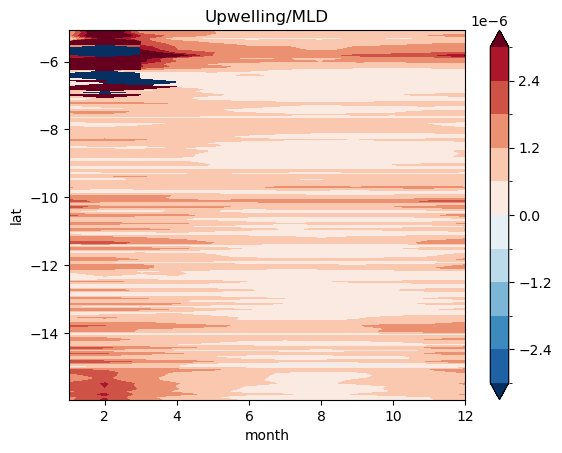

In [151]:
seasonality(UP_MLD).mean('lon').sel(lat=slice(-16,-5)).plot.contourf(x='month',levels=10,robust=True)
plt.title('Upwelling/MLD')

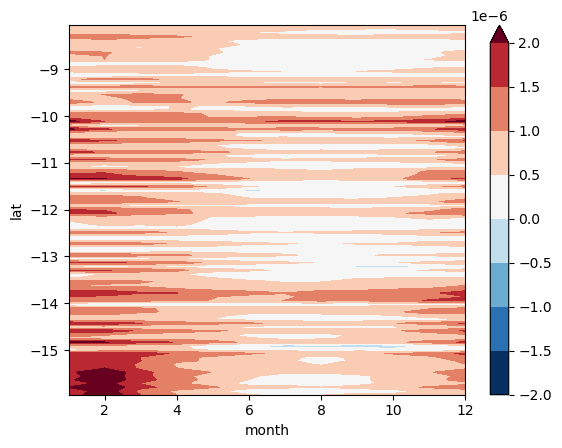

In [155]:
UP_season = seasonality(UP_MLD).mean('lon').sel(lat=slice(-16,-8))
UP_season.where(UP_season>-1e7,np.nan).plot.contourf(levels=10,x='month',robust=True)
# UP_season.plot.contourf(levels=10,x='month',robust=True)

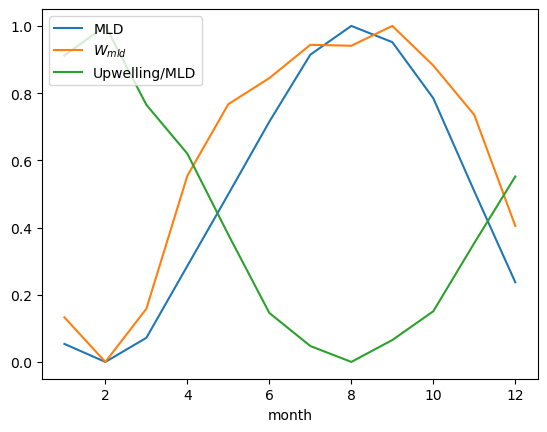

In [156]:
normalize(seasonality(MLD_ds).mean('lon').sel(lat=slice(-16,-8)).mean('lat').MLD).plot(label='MLD')
normalize(wmld.sel(lat=slice(-16, -8)).mean(dim='lat')).plot(label='$W_{mld}$')
normalize(UP_season.where(UP_season>-1e7,np.nan).mean('lat')).plot(label='Upwelling/MLD')
plt.legend()